<a href="https://colab.research.google.com/github/MohylinaDiana/python_for_ds_tasks/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('drive/MyDrive/yulu_bike_sharing_dataset.csv')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [5]:
def get_india_season(month):
    if month in [12, 1, 2]:
        return 1
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8, 9]:
        return 3
    else:
        return 4

df['weather_season_india'] = df['month'].apply(get_india_season)


print(f"Розмір датасету: {df.shape}")
print(df.head())

Розмір датасету: (10886, 20)
                     season  holiday  workingday  weather  temp   atemp  \
datetime                                                                  
2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

                     humidity  windspeed  casual  registered  count  \
datetime                                                              
2011-01-01 00:00:00        81        0.0       3          13     16   
2011-01-01 01:00:00        80        0.0       8          32     40   
2011-01-01 02:00:00        80        0.0       5          27     32   
2011-01-01 03:00:00        75        0.0       3          10     13   
2011-01-01 04:00:00

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


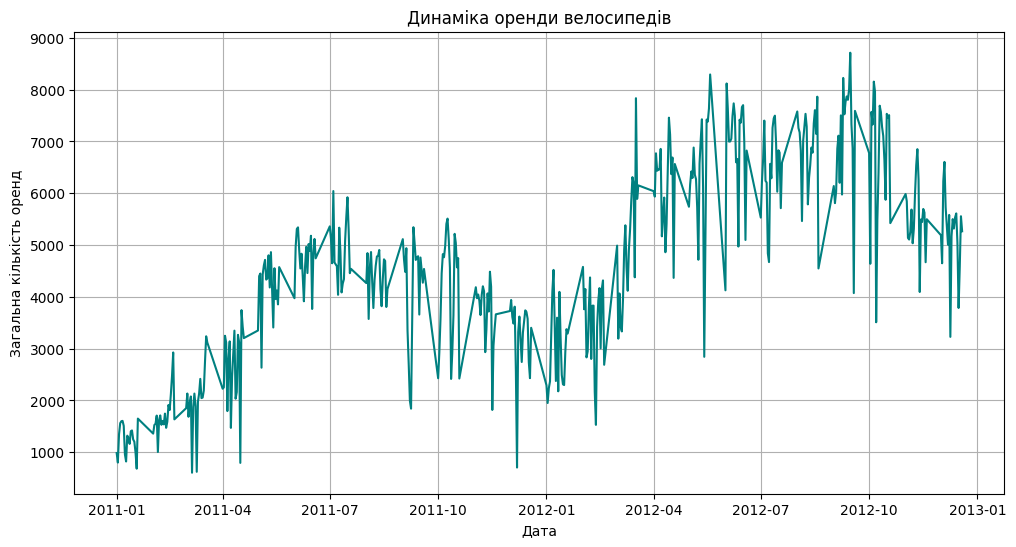

In [7]:
df['date'] = df.index.date

daily_rentals = df.groupby('date')['count'].sum()

daily_rentals.plot(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    grid=True,
    color='teal',
    linewidth=1.5
)

plt.xlabel('Дата')
plt.ylabel('Загальна кількість оренд')
plt.show()

1.Чому бувають заломи?: Через різницю між будніми та вихідними днями, а також через зміну погоди.
Як прибрати:
Групувати дані по тижнях чи місяцях.

2.Які загальні тенденції?
З часом кількість оренд зростає.
У другому році попит вищий, ніж у першому.

3.Чи є сезонність?
Так.
Навесні та влітку оренд більше, взимку — значно менше.

4.Чи є аномалії?
Так.
Різкі спади та підйоми


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

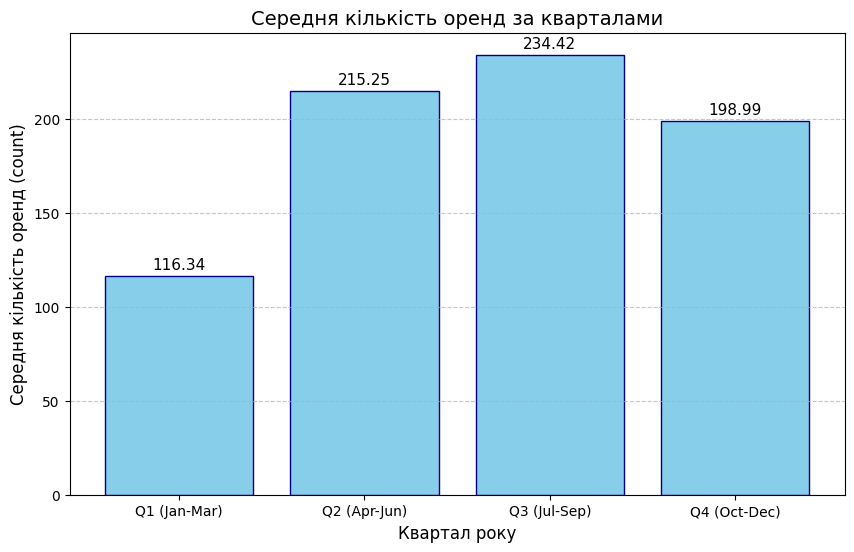

In [8]:
season_names = {1: 'Q1 (Jan-Mar)', 2: 'Q2 (Apr-Jun)', 3: 'Q3 (Jul-Sep)', 4: 'Q4 (Oct-Dec)'}

seasonal_avg = df.groupby('season')['count'].mean()
seasonal_avg.index = seasonal_avg.index.map(season_names)

plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_avg.index, seasonal_avg.values, color='skyblue', edgecolor='navy')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, round(yval, 2), ha='center', va='bottom', fontsize=11)

plt.title('Середня кількість оренд за кварталами', fontsize=14)
plt.xlabel('Квартал року', fontsize=12)
plt.ylabel('Середня кількість оренд (count)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

1.Найбільша оренда: У 3-му кварталі

2.Чому в Q3 найбільша к-сть оренди: Це найтепліший період, що ідеально для прогулянок.

3.Наскільки відрізняється?: Оренда влітку Q3 приблизно у 2 рази вища, ніж взимку Q1.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


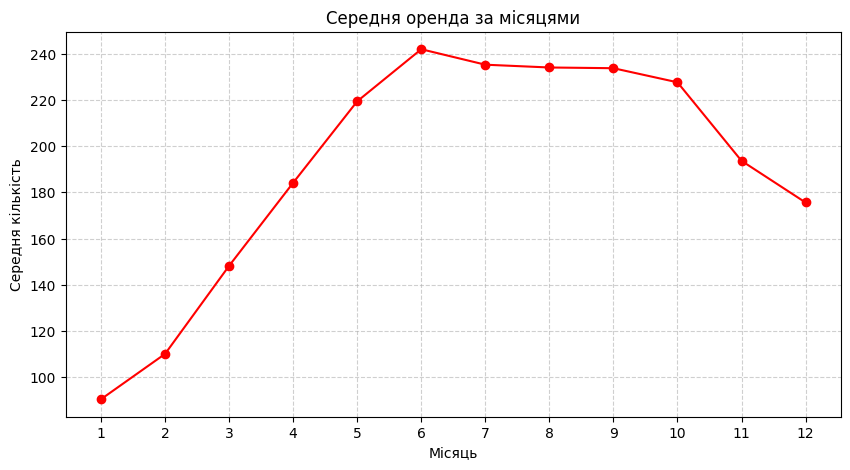

In [9]:
monthly_avg = df.groupby('month')['count'].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, color='red', marker='o', linestyle='-')

plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Середня оренда за місяцями')
plt.xlabel('Місяць')
plt.ylabel('Середня кількість')

plt.show()

1.Пік та спад: Пік припадає на червень–серпень (6-8 місяці), а найглибший спад — на січень (1 місяць).

2.Збіжність: Так, це повністю підтверджує дані з попереднього завдання (найвищий попит у 3-му кварталі, найнижчий — у 1-му).

3.Вплив клімату: Екстремальні температури та опади є головними факторами зниження оренди. Комфортне тепло стимулює попит.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

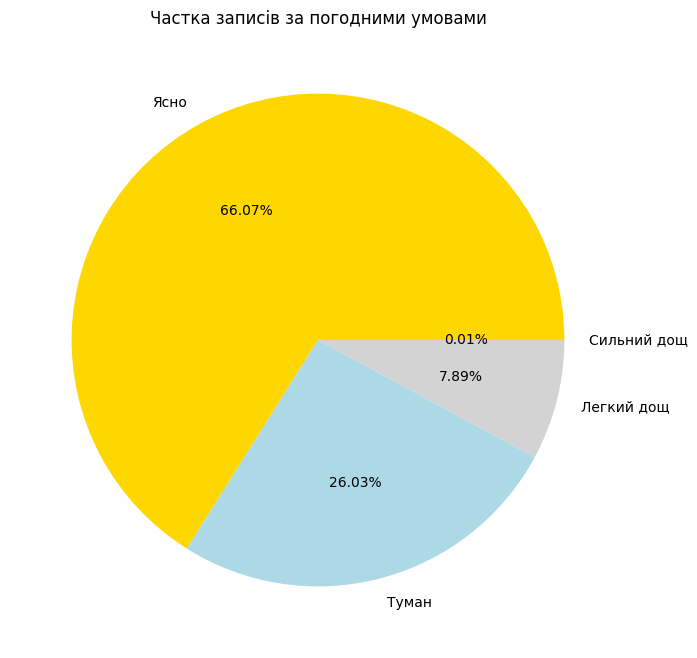

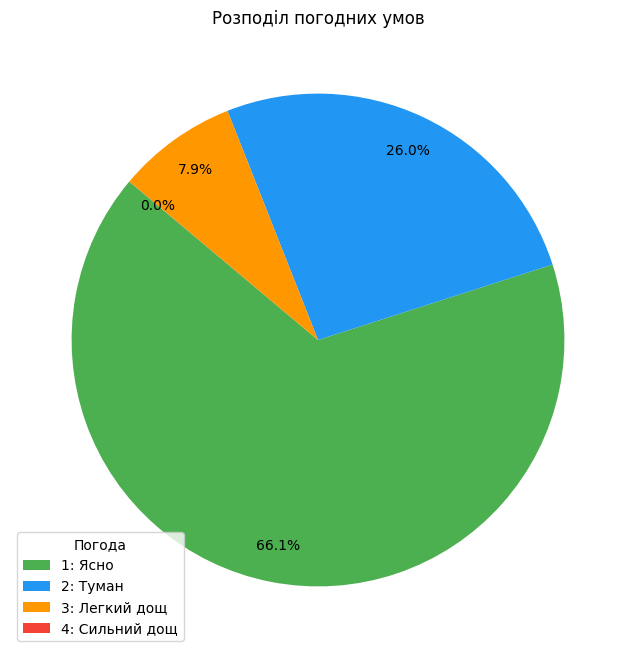

In [11]:
weather_counts = df['weather'].value_counts()

labels = ['1: Ясно', '2: Туман', '3: Легкий дощ', '4: Сильний дощ']
custom_colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']

plt.figure(figsize=(8, 8))
plt.pie(weather_counts,
        autopct='%1.1f%%',
        colors=custom_colors,
        startangle=140,
        pctdistance=0.85)

plt.legend(labels, title="Погода", loc="best")
plt.title("Розподіл погодних умов")
plt.show()

1.Яка погода переважає?: Переважає ясна погода — вона становить приблизно 66% усіх записів.

2.Чи є дні із сильним дощем?: Так, але їхня частка мізерна — лише 0.01%.

3.Як погода впливає на попит?: Погода є критичним фактором: чим гірші умови, тим сильніше падає попит. Більшість оренд припадає на "ясні" та "туманні" дні.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

/tmp/ipython-input-1135/1421590218.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(weather_groups, vert=False, labels=weather_labels, patch_artist=True)


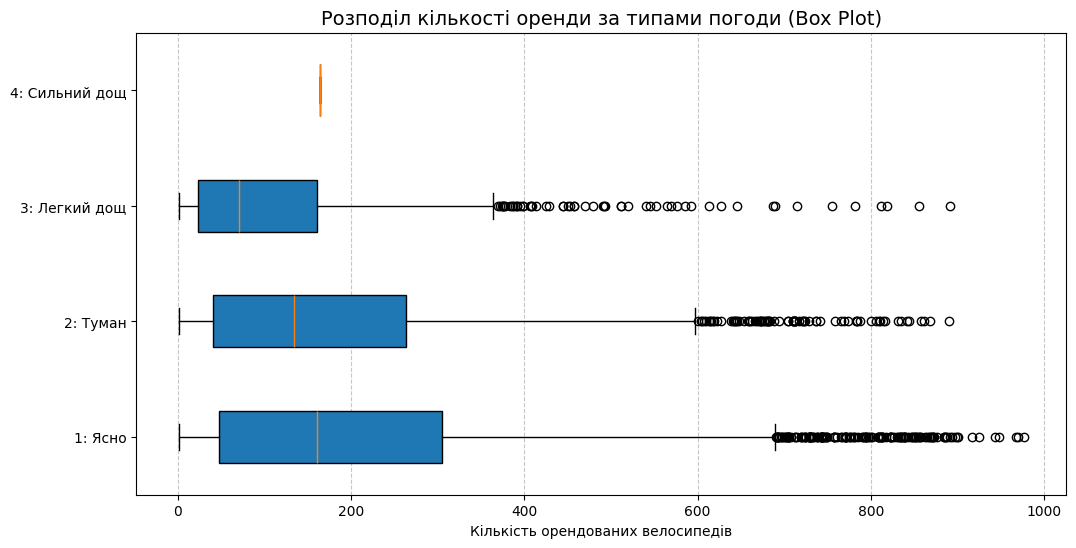

In [14]:
weather_groups = [df[df['weather'] == i]['count'] for i in range(1, 5)]
weather_labels = ['1: Ясно', '2: Туман', '3: Легкий дощ', '4: Сильний дощ']
plt.figure(figsize=(12, 6))
plt.boxplot(weather_groups, vert=False, labels=weather_labels, patch_artist=True)

plt.title('Розподіл кількості оренди за типами погоди (Box Plot)', fontsize=14)
plt.xlabel('Кількість орендованих велосипедів')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

1.Найбільший розкид: При Погоді 1. Тут найширший діапазон значень.

2.Викиди: Так, їх багато при Погоді 1, 2 та 3. Це години аномально високого попиту.

3.Найвища медіана: При Погоді 1. Це підтверджує, що за такої погоди люди беруть велосипеди найчастіше.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

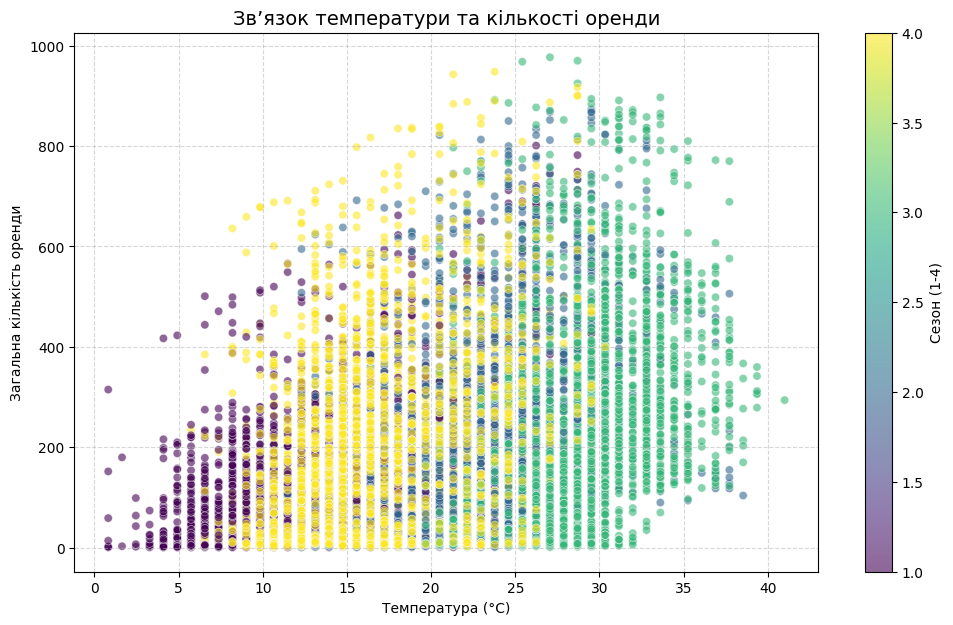

In [15]:
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    df['temp'],
    df['count'],
    c=df['season'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5
)

plt.colorbar(scatter, label='Сезон (1-4)')

plt.title('Зв’язок температури та кількості оренди', fontsize=14)
plt.xlabel('Температура (°C)')
plt.ylabel('Загальна кількість оренди')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

1.Чи є зв'язок? Так, існує позитивна кореляція.
2.Зв'язок позитивний: чим тепліше, тим більше оренд.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?